In [1]:
from dataset import *
from evaluate import *
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [2]:
# df7 = pd.read_csv('edentonbay.csv', parse_dates=['date'],infer_datetime_format='%m/%d/%Y').sort_values(by='date')
# df8 = pd.read_csv('chowan_beach.csv', parse_dates=['date'],infer_datetime_format='%m/%d/%Y').sort_values(by='date')
# df9 = pd.read_csv('sound.csv', parse_dates=['date'],infer_datetime_format='%m/%d/%Y').sort_values(by='date')
# df10 = pd.read_csv('a7.csv', parse_dates=['date'],infer_datetime_format='%m/%d/%Y').sort_values(by='date')
# df11 = pd.read_csv('perq.csv', parse_dates=['date'],infer_datetime_format='%m/%d/%Y').sort_values(by='date')
# df7['date'] = df7['date'].dt.strftime('%m-%d-%Y')
# df8['date'] = df8['date'].dt.strftime('%m-%d-%Y')
# df9['date'] = df9['date'].dt.strftime('%m-%d-%Y')
# df10['date'] = df10['date'].dt.strftime('%m-%d-%Y')
# df11['date'] = df11['date'].dt.strftime('%m-%d-%Y')
# df7 = df7.loc[df7['pred']==1].drop_duplicates()
# df8 = df8.loc[df8['pred']==1].drop_duplicates()
# df9 = df9.loc[df9['pred']==1].drop_duplicates()
# df10 = df10.loc[df10['pred']==1].drop_duplicates()
# df11 = df11.loc[df11['pred']==1].drop_duplicates()

# df = pd.read_csv('csvs/alldata.csv', parse_dates=['date'],infer_datetime_format='%m/%d/%Y').sort_values(by='date')
# df['date'] = df['date'].dt.strftime('%m-%d-%Y')

# df1 = df.loc[df['spot'] == 'chowan_river']
# df2 = df.loc[df['spot'] == 'arrowhead_beach']
# df3 = df.loc[df['spot'] == 'cannons_ferry']
# df4 = df.loc[df['spot'] == 'point_comfort']
# df5 = df.loc[df['spot'] == 'mt_gould']
# df6 = df.loc[df['spot'] == 'rocky_hock_lane']

# df1 = df1.loc[(df1['label'] == 1) & (df1['pred'] ==1)].drop_duplicates(subset=['date'])
# df2 = df2.loc[(df2['label'] == 1) & (df2['pred'] ==1)].drop_duplicates(subset=['date'])
# df3 = df3.loc[(df3['label'] == 1) & (df3['pred'] ==1)].drop_duplicates(subset=['date'])
# df4 = df4.loc[(df4['label'] == 1) & (df4['pred'] ==1)].drop_duplicates(subset=['date'])
# df5 = df5.loc[(df5['label'] == 1) & (df5['pred'] ==1)].drop_duplicates(subset=['date'])
# df6 = df6.loc[(df6['label'] == 1) & (df6['pred'] ==1)].drop_duplicates(subset=['date'])

# # df1 = df1.loc[(df1['pred'] ==1)].drop_duplicates(subset=['date'])
# # df2 = df2.loc[(df2['pred'] ==1)].drop_duplicates(subset=['date'])
# # df3 = df3.loc[(df3['pred'] ==1)].drop_duplicates(subset=['date'])
# # df4 = df4.loc[(df4['pred'] ==1)].drop_duplicates(subset=['date'])
# # df5 = df5.loc[(df5['pred'] ==1)].drop_duplicates(subset=['date'])
# # df6 = df6.loc[(df6['pred'] ==1)].drop_duplicates(subset=['date'])

In [3]:
import pandas as pd

# Read and preprocess the data
df = (
    pd.read_csv('csvs/alldata.csv', parse_dates=['date'], infer_datetime_format=True)
    .sort_values(by='date')
)
df['date'] = df['date'].dt.strftime('%m-%d-%Y')

# List of spot names
spots = [
    'chowan_river', 
    'arrowhead_beach', 
    'cannons_ferry', 
    'point_comfort', 
    'mt_gould', 
    'rocky_hock_lane'
]

# Dictionary to store filtered DataFrames
filtered_dfs = {}
date_range = pd.date_range(start='2016-01-01', end='2024-06-30', freq='D').strftime('%m-%d-%Y')

# Function to expand a DataFrame to cover the entire date range
def expand_dataframe(df, date_range):
    # Create a DataFrame with the complete date range
    full_dates = pd.DataFrame({'date': date_range})
    # Merge with the original DataFrame
    expanded_df = full_dates.merge(df, on='date', how='left')
    # Fill missing values with 0
    expanded_df[['label', 'pred']] = expanded_df[['label', 'pred']].fillna(0).astype(int)
    return expanded_df

# Iterate through spots, filter, and preprocess
for spot in spots:
    filtered_dfs[spot] = (
        df.loc[(df['spot'] == spot) & (df['pred'] == 1)]  # Filter by spot and prediction
        .drop_duplicates(subset=['date'])                # Remove duplicates by date
        .drop('spot', axis=1)                            # Drop the 'spot' column
    )

# Access each DataFrame by its spot name
df1 = filtered_dfs['chowan_river']
df2 = filtered_dfs['arrowhead_beach']
df3 = filtered_dfs['cannons_ferry']
df4 = filtered_dfs['point_comfort']
df5 = filtered_dfs['mt_gould']
df6 = filtered_dfs['rocky_hock_lane']

for spot, spot_df in filtered_dfs.items():
    filtered_dfs[spot] = expand_dataframe(spot_df, date_range)

# Access expanded DataFrames as needed
df1 = filtered_dfs['chowan_river']
df2 = filtered_dfs['arrowhead_beach']
df3 = filtered_dfs['cannons_ferry']
df4 = filtered_dfs['point_comfort']
df5 = filtered_dfs['mt_gould']
df6 = filtered_dfs['rocky_hock_lane']

In [4]:
csv_files = [
    'edentonbay.csv',
    'northchowan.csv',
#     'chowan_beach.csv',
    'midchowan.csv',
    'bridge.csv',
    'albemarle.csv'
]

def preprocess_and_expand(file, date_range):
    df = (
        pd.read_csv(file, parse_dates=['date'], infer_datetime_format=True)
        .sort_values(by='date')
    )
    df['date'] = df['date'].dt.strftime('%m-%d-%Y')
    df = df.loc[df['pred'] == 1].drop_duplicates()  # Filter and remove duplicates
    # Expand to the full date range
    full_dates = pd.DataFrame({'date': date_range})
    expanded_df = full_dates.merge(df, on='date', how='left')
    expanded_df[['pred']] = expanded_df[[ 'pred']].fillna(0).astype(int)
    return expanded_df

processed_dfs = {}

for file in csv_files:
    # Use the file name without extension as the key for clarity
    key = file.split('.')[0]
    processed_dfs[key] = preprocess_and_expand(file, date_range)

# Access processed DataFrames
df7 = processed_dfs['edentonbay']
# df8 = processed_dfs['chowan_beach']
df9 = processed_dfs['midchowan']
df9 = processed_dfs['northchowan']
df10 = processed_dfs['albemarle']
df11= processed_dfs['bridge']

In [5]:
# df7 = df7.loc[(df7['pred']==1)].drop_duplicates(subset=['date'])

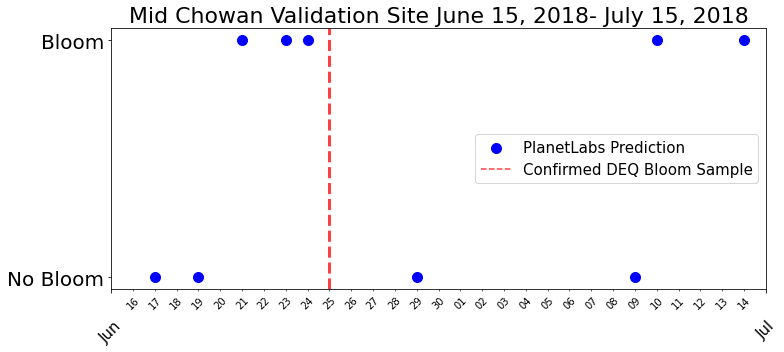

In [6]:
#bridge midchowan edenton northchowan albemarle
df7 = pd.read_csv('midchowan.csv', parse_dates=['date'], infer_datetime_format=True).sort_values(by='date')
df7 = df7.drop_duplicates(subset=['date'])
site = 'midchowan' 

d= pd.read_excel('Sites with algal cell data V2.xlsx',header=0)#, parse_dates=['date'], infer_datetime_format=True)
d = d.drop(['albemarle', 'northchowan', 'edenton','bridge'], axis=1)  
d = d.drop(d.columns[d.columns.str.startswith('Unnamed:')], axis=1)
# print(d)
# d[site][d[site] != 0] = 1
# d = d.loc[(d[site] ==1)].drop_duplicates(subset=['DEQ'])

d['DEQ'] = pd.to_datetime(d['DEQ'])
d9 = d['DEQ']
l9 = d[site]

df7['date'] = pd.to_datetime(df7['date'])
d = df7['date']
l = df7['pred']
# Create the plot

fig, ax = plt.subplots(1, 1, figsize=(11,5))
ax.scatter(d, l, c='b', label= 'PlanetLabs Prediction' , s=100)
# ax.scatter(d9, l9, c='r', s=120, label = 'DEQ Sample')
ax.set_xlim(pd.to_datetime('2018-06-15'), pd.to_datetime('2018-07-15'))

for (date, ll) in zip(d9, l9):
    if ll > 20000:
        
#     print(date, ll)
#     if l9 != 0:
        
        plt.axvline(x=date, color='red', alpha=0.75, linestyle = '--', lw=3, label='_nolegend_')
    
    else:  plt.axvline(x=date, color='black', alpha=0.75, linestyle = '--', label='_nolegend_')
        
ax.axvline(x=d9.iloc[0], color='red', alpha=0.75,linestyle='--', label='Confirmed DEQ Bloom Sample')
# ax.axvline(x=d9.iloc[0], color='black', alpha=0.75,linestyle='--', label='DEQ Sample')

# ####OVERVIEW OF ALL YEARS
# ax.xaxis.set_major_locator(mdates.YearLocator())  # Major ticks: every year
# ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))  # Minor ticks: every 3 months
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Major labels: year only
# ax.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))  # Minor labels: month abbreviation
# def custom_minor_formatter(x, pos):
#     if pos % 3 == 0:  # Only label every 3rd month
#         return mdates.num2date(x).strftime('%b')
#     else:
#         return ""

###### MONTHLY OVER ONE YEAR
ax.xaxis.set_major_locator(mdates.MonthLocator(1))  # Major ticks: every year
ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))  # Minor ticks: every 3 months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Major labels: year only
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%d'))  # Minor labels: month abbreviation
def custom_minor_formatter(x, pos):
    if pos % 1 == 0:  # Only label every 3rd month
        return mdates.num2date(x).strftime('%d')
    else:
        return ""
labels = ['No Bloom','Bloom']
ax.xaxis.set_minor_formatter(plt.FuncFormatter(custom_minor_formatter))
ax.tick_params(axis='x', which='minor', rotation=45)
ax.tick_params(axis='x', which='major', labelsize=15, pad=25, rotation=45)
ax.tick_params(axis='y', labelsize = 20)
ax.set_yticks([0,1])
ax.set_yticklabels(labels)
ax.set_title(f'Mid Chowan Validation Site June 15, 2018- July 15, 2018', fontsize=22)
# ax.set_ylabel( fontsize=14)
ax.legend(loc=5, fontsize=15)
plt.tight_layout()

plt.savefig('midchowan_time.png', dpi=300, facecolor='white', bbox_inches='tight')
plt.show()


In [8]:
df7 = df7.iloc[55:90].reset_index(drop=True)

In [19]:
df7.iloc[189:200].drop_duplicates(subset=['date'])

,date,pred
1018,2018-06-19,0
1327,2018-06-21,1
885,2018-06-23,1
1039,2018-06-24,1
31,2018-06-29,0
853,2018-07-09,0
701,2018-07-10,1
1403,2018-07-14,1


In [40]:
# Define sites for each DataFrame
sites = ['chowan_beach', 'arrowhead_beach', 'cannons_ferry', 'point_comfort', 'rocky_hock_lane']
dfs = [df8, df2, df3, df4, df6]

# Initialize an empty dictionary to store dates and corresponding site names
date_sites = {}

# Iterate through each DataFrame and its corresponding site name
for site_name, df in zip(sites, dfs):
    # Filter unique dates for the current site
    for date in df['date'].unique():
        # Add the date to the dictionary or append the site name if the date already exists
        if date not in date_sites:
            date_sites[date] = [site_name]
        else:
            date_sites[date].append(site_name)

# Sort the dictionary by date
sorted_date_sites = {date: sites for date, sites in sorted(date_sites.items())}

In [41]:
from datetime import datetime

# Sort the dictionary by date (converted to datetime for proper sorting)
sorted_date_sites = {
    date: sites
    for date, sites in sorted(date_sites.items(), key=lambda x: datetime.strptime(x[0], '%m-%d-%Y'))
}


In [42]:
# Combine all dates into one DataFrame
all_dates = pd.concat([df[['date']] for df in dfs])

# Count occurrences of each date
date_counts = all_dates['date'].value_counts().reset_index()

# # Rename columns to match desired output
date_counts.columns = ['date', 'count']

# Sort by date if necessary
# date_counts = date_counts.sort_values(by='date').reset_index(drop=True)
date_counts['date'] = pd.to_datetime(date_counts['date'])
date_counts['date']= date_counts['date'].dt.strftime('%Y-%m-%d')
trained = date_counts.sort_values(by='date')

In [31]:
trained['date'] = pd.to_datetime(trained['date'])
d = trained['date']
l = trained['count']

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# First plot (in black)
# ax.scatter(d, l, c='g', label='trained',lw=1.5, alpha = 0.5)

# Second plot (in blue)
ax.plot(d, l, c='b', lw=1.5, label='unlabeled')

# Customize x-axis ticks and labels
ax.xaxis.set_major_locator(mdates.YearLocator())  # Major ticks: every year
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))  # Minor ticks: every 3 months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Major labels: year only
# ax.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))  # Minor labels: month abbreviation
def custom_minor_formatter(x, pos):
    if pos % 3 == 0:  # Only label every 3rd month
        return mdates.num2date(x).strftime('%b')
    else:
        return ""

ax.xaxis.set_minor_formatter(plt.FuncFormatter(custom_minor_formatter))

ax.tick_params(axis='x', which='minor', rotation=45)
ax.tick_params(axis='x', which='major', labelsize=15, pad=25)

ax.set_title('Comparison of Model Predicted Blooms Over Northern Sites', fontsize=25)
ax.set_ylabel('Count of locations total', fontsize=14)
ax.set_xlabel('Date', fontsize=14)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

# fig.savefig('trained.png', transparent=False, facecolor='white', bbox_inches='tight')


NameError: name 'trained' is not defined

In [44]:
sites = ['a7', 'mt_gould','chowan_river', 'edenton_bay','abemarle_sound']
dfs = [df10, df5, df1, df7, df9]

date_sites = {}

for site_name, df in zip(sites, dfs):
    for date in df['date'].unique():
        if date not in date_sites:
            date_sites[date] = [site_name]
        else:
            date_sites[date].append(site_name)

sorted_date_sites = {date: sites for date, sites in sorted(date_sites.items())}
from datetime import datetime

sorted_date_sites = {
    date: sites
    for date, sites in sorted(date_sites.items(), key=lambda x: datetime.strptime(x[0], '%m-%d-%Y'))
}

In [45]:
from datetime import datetime

# Sort the dictionary by date (converted to datetime for proper sorting)
sorted_date_sites = {
    date: sites
    for date, sites in sorted(date_sites.items(), key=lambda x: datetime.strptime(x[0], '%m-%d-%Y'))
}


In [46]:

# Combine all dates into one DataFrame
all_dates = pd.concat([df[['date']] for df in dfs])

# Count occurrences of each date
date_counts = all_dates['date'].value_counts().reset_index()

# # Rename columns to match desired output
date_counts.columns = ['date', 'count']

# Sort by date if necessary
# date_counts = date_counts.sort_values(by='date').reset_index(drop=True)
date_counts['date'] = pd.to_datetime(date_counts['date'])
date_counts['date']= date_counts['date'].dt.strftime('%Y-%m-%d')
unlabeled = date_counts.sort_values(by='date')

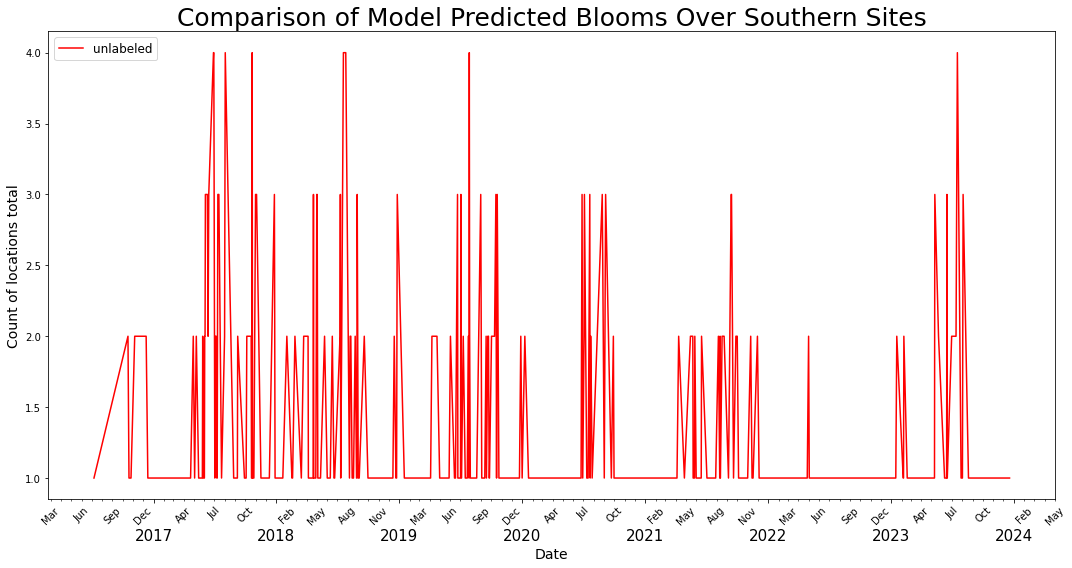

In [47]:
unlabeled['date'] = pd.to_datetime(unlabeled['date'])
second_d = unlabeled['date']
second_l = unlabeled['count']

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# First plot (in black)
# ax.scatter(d, l, c='g', label='trained',lw=1.5, alpha = 0.5)

# Second plot (in blue)
ax.plot(second_d, second_l, c='r', lw=1.5, label='unlabeled')

# Customize x-axis ticks and labels
ax.xaxis.set_major_locator(mdates.YearLocator())  # Major ticks: every year
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))  # Minor ticks: every 3 months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Major labels: year only
# ax.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))  # Minor labels: month abbreviation
def custom_minor_formatter(x, pos):
    if pos % 3 == 0:  # Only label every 3rd month
        return mdates.num2date(x).strftime('%b')
    else:
        return ""

ax.xaxis.set_minor_formatter(plt.FuncFormatter(custom_minor_formatter))

ax.tick_params(axis='x', which='minor', rotation=45)
ax.tick_params(axis='x', which='major', labelsize=15, pad=25)

ax.set_title('Comparison of Model Predicted Blooms Over Southern Sites', fontsize=25)
ax.set_ylabel('Count of locations total', fontsize=14)
ax.set_xlabel('Date', fontsize=14)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

# fig.savefig('unlabeled.png', transparent=False, facecolor='white', bbox_inches='tight')


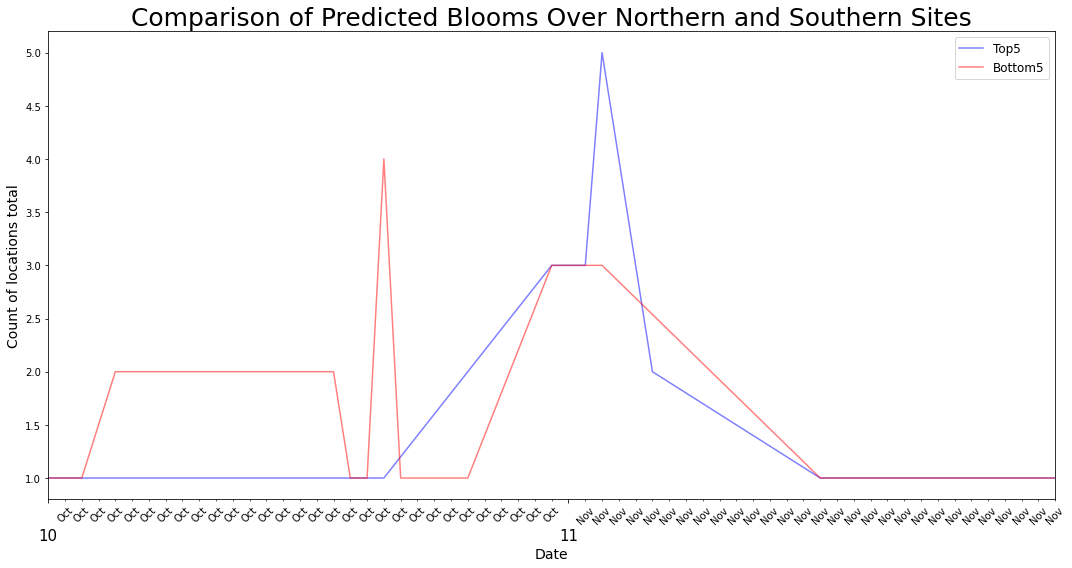

In [54]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

fig, ax = plt.subplots(1, 1, figsize=(15, 8))

ax.plot(d, l, c='b', label='Top5',lw=1.5, alpha = 0.5)
ax.plot(second_d, second_l, c='r', lw=1.5, label='Bottom5', alpha=0.5)

# Customize x-axis ticks and labels
ax.set_xlim(pd.to_datetime('2017-10-01'), pd.to_datetime('2017-11-30'))

ax.xaxis.set_major_locator(mdates.MonthLocator())  # Major ticks: every year
ax.xaxis.set_minor_locator(mdates.DayLocator(interval=1))  # Minor ticks: every 3 months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m'))  # Major labels: year only
ax.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))  # Minor labels: month abbreviation
def custom_minor_formatter(x, pos):
    if pos % 1 == 0:  # Only label every 3rd month
        return mdates.num2date(x).strftime('%b')
    else:
        return ""

ax.xaxis.set_minor_formatter(plt.FuncFormatter(custom_minor_formatter))

ax.tick_params(axis='x', which='minor', rotation=45)
ax.tick_params(axis='x', which='major', labelsize=15, pad=25)

ax.set_title('Comparison of Predicted Blooms Over Northern and Southern Sites', fontsize=25)
ax.set_ylabel('Count of locations total', fontsize=14)
ax.set_xlabel('Date', fontsize=14)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

# fig.savefig('nortevsur.png', transparent=False, facecolor='white', bbox_inches='tight')
